In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import PchipInterpolator

R_gas = 8.314472

## Load data

In [2]:
janaf_H2S = np.loadtxt("janaf_H2S.dat").T
H2S_t = janaf_H2S[0] # K
H2S_G = janaf_H2S[6] * 1e3 # J/mol

janaf_S2  = np.loadtxt("janaf_S2.dat").T
S2_t = janaf_S2[0] # K
S2_G = janaf_S2[6] * 1e3 # J/mol

H2_t = np.array(S2_t) # K
H2_G = np.zeros_like(H2_t) # H2 is in its standard state

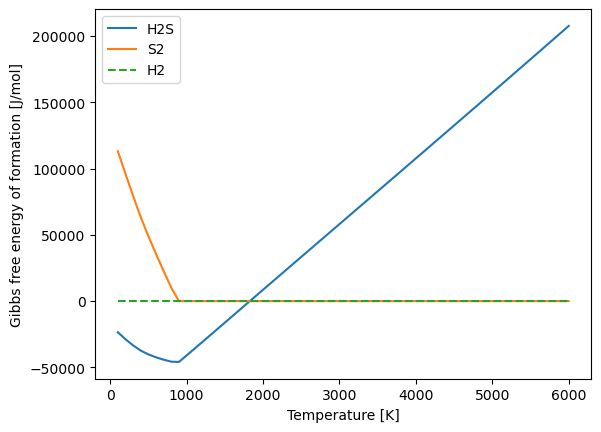

In [3]:
fig,ax = plt.subplots(1,1)

ax.plot(H2S_t, H2S_G, label="H2S")
ax.plot(S2_t,  S2_G , label="S2")
ax.plot(H2_t,  H2_G , label="H2", ls='dashed')

ax.set(xlabel="Temperature [K]", ylabel="Gibbs free energy of formation [J/mol]")
ax.legend()
plt.show()

## Interpolate

In [4]:
itp_H2S = PchipInterpolator(H2S_t, H2S_G)
itp_S2 = PchipInterpolator(S2_t, S2_G)
itp_H2 = PchipInterpolator(H2_t, H2_G)

## Formulate reaction

In [5]:
def eval_deltaG(tmp):
    g_H2S = itp_H2S(tmp)
    g_S2 = itp_S2(tmp)
    g_H2 = itp_H2(tmp)
    return g_H2S - g_S2 - g_H2

def eval_Keq(tmp):
    return np.exp(-eval_deltaG(tmp)/(R_gas*tmp))

## Fit curve to log10(K_eq) values

In [74]:
tmp_arr = np.arange(200.0, 4000.0, 5)
keq_arr = np.array([eval_Keq(tmp) for tmp in tmp_arr])

In [75]:
def fit_line(x,a,b):
    return a + b*x
opt_line, _ = curve_fit(fit_line, tmp_arr, np.log10(keq_arr))
print(opt_line)

[ 8.80523993e+00 -3.38519367e-03]


In [76]:
def fit_poly(x,a,b,c,d):
    return a + b*x + c*x**2 + d*x**3
opt_poly, _ = curve_fit(fit_poly, tmp_arr, np.log10(keq_arr))
print(opt_poly)

[ 2.64956900e+01 -3.62938111e-02  1.51116718e-05 -1.98410792e-09]


In [77]:
def fit_expo(x, a, b):
    return a/x - b
opt_expo, _ = curve_fit(fit_expo, tmp_arr, np.log10(keq_arr))
print(opt_expo)

[6.73101547e+03 3.62273031e+00]


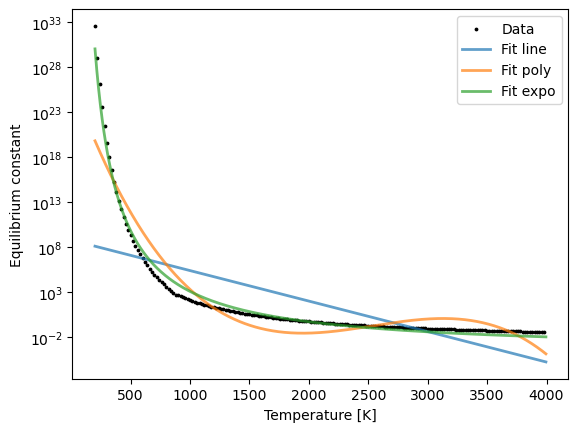

In [78]:
fig,ax = plt.subplots(1,1)

ax.scatter(tmp_arr[::4],  keq_arr[::4], s=3, label="Data", c='k')
ax.plot(tmp_arr,  10**fit_line(tmp_arr, *opt_line), lw=2, label="Fit line", alpha=0.7)
ax.plot(tmp_arr,  10**fit_poly(tmp_arr, *opt_poly), lw=2, label="Fit poly", alpha=0.7)
ax.plot(tmp_arr,  10**fit_expo(tmp_arr, *opt_expo), lw=2, label="Fit expo", alpha=0.7)

ax.set(xlabel="Temperature [K]", ylabel="Equilibrium constant")
ax.set_yscale("log")
ax.legend()
plt.show()